# Selection pipeline analysis — IF vs CNN vs combinations

Five questions about the **selection pipeline** (before/around modeling):

1. How clean are Rachel's geometric candidates to begin with? Fractions of Poultry / OtherFarm / NotFarm.
2. Does the **Isolation Forest** `template_score_if` actually improve precision without killing recall?
3. Same question for the **CNN** (`baseline_v2` binary farm-vs-notfarm).
4. Is one model clearly better than the other?
5. Does combining them — score averaging, or **sequential IF → CNN** — beat either alone?

**Evaluation set:** the 15,512 labeled clusters from `all_clusters.parquet` (5 main countries + 48 long-tail inspected). Binary farm/not-farm ground truth (`final_label == 'NotFarm'`).

In [1]:
import json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    precision_recall_curve, roc_curve, precision_score, recall_score,
)

ROOT = Path('..').resolve()

# Source data + IF scores
raw = pd.read_parquet(ROOT / 'data/rachel_geometry_candidates/all_countries/all_clusters.parquet')
raw = raw[raw['final_label'].notna() & (raw['final_label'] != 'Ambiguous')].copy()

# CNN binary scores from baseline_v2 inference on all clusters
cnn = pd.read_parquet(ROOT / 'data/output/baseline_v2_all_clusters/scored_candidates.parquet')
cnn = cnn[['candidate_id', 'predicted_score']].rename(
    columns={'candidate_id': 'cluster_id', 'predicted_score': 'cnn_score'})

# Join on cluster_id
df = raw.merge(cnn, on='cluster_id', how='inner')
df['cnn_score'] = df['cnn_score'].astype(float)
df['if_score']  = df['template_score_if'].astype(float)

# Labels
df['is_farm']   = (df['final_label'] != 'NotFarm').astype(int)
df['three_way'] = df['final_label'].apply(
    lambda x: 'NotFarm' if x == 'NotFarm' else ('Poultry' if 'Poultry' in x else 'OtherFarm'))

print(f'Labeled clusters with both IF + CNN scores: {len(df):,}')
print(f'IF score range: [{df["if_score"].min():.3f}, {df["if_score"].max():.3f}]')
print(f'CNN score range: [{df["cnn_score"].min():.3f}, {df["cnn_score"].max():.3f}]')

Labeled clusters with both IF + CNN scores: 15,489
IF score range: [-0.247, 0.203]
CNN score range: [0.000, 1.000]


## Q1 — How clean is the candidate pool?

Fractions in the labeled set (which we treat as representative of the wider candidate pool of ~101 k for the purposes of this analysis; about 15 % of the pool is labeled).

              n   pct
three_way            
Poultry    9247  59.7
NotFarm    3616  23.3
OtherFarm  2626  17.0

Binary: farms = 76.7 %, not-farms = 23.3 %


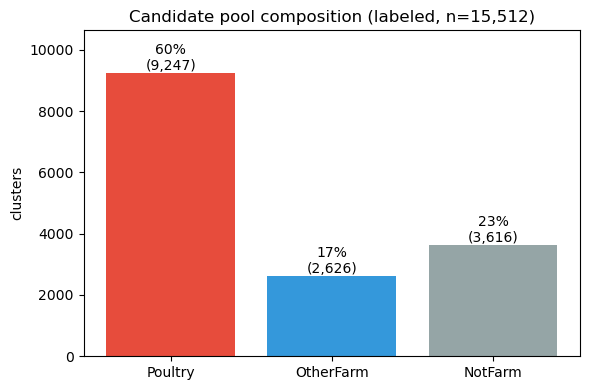

In [2]:
tw = df['three_way'].value_counts()
frac = (tw / tw.sum() * 100).round(1)
comp = pd.DataFrame({'n': tw, 'pct': frac})
print(comp.to_string())
print()
print(f'Binary: farms = {df["is_farm"].mean()*100:.1f} %, not-farms = {(1-df["is_farm"].mean())*100:.1f} %')

fig, ax = plt.subplots(figsize=(6, 4))
colors = {'Poultry': '#e74c3c', 'OtherFarm': '#3498db', 'NotFarm': '#95a5a6'}
for i, k in enumerate(['Poultry', 'OtherFarm', 'NotFarm']):
    ax.bar(k, tw[k], color=colors[k])
    ax.text(i, tw[k], f'{frac[k]:.0f}%\n({tw[k]:,})', ha='center', va='bottom', fontsize=10)
ax.set_ylabel('clusters'); ax.set_title('Candidate pool composition (labeled, n=15,512)')
ax.set_ylim(0, tw.max() * 1.15)
plt.tight_layout(); plt.show()

**Headline**: Rachel's geometric clustering is already heavily enriched for farms — about 77 % of labeled candidates are farms. The pool is roughly **60 % Poultry / 17 % OtherFarm / 23 % NotFarm**. A trivial 'always predict farm' classifier already achieves **77 % precision at 100 % recall** on this pool — a high bar for any downstream model to beat.

## Q2 — Does the Isolation Forest help?

`template_score_if` is signed; higher = more farm-like. Plot score distributions per class, then ROC + PR curves, and quote precision at fixed recall.

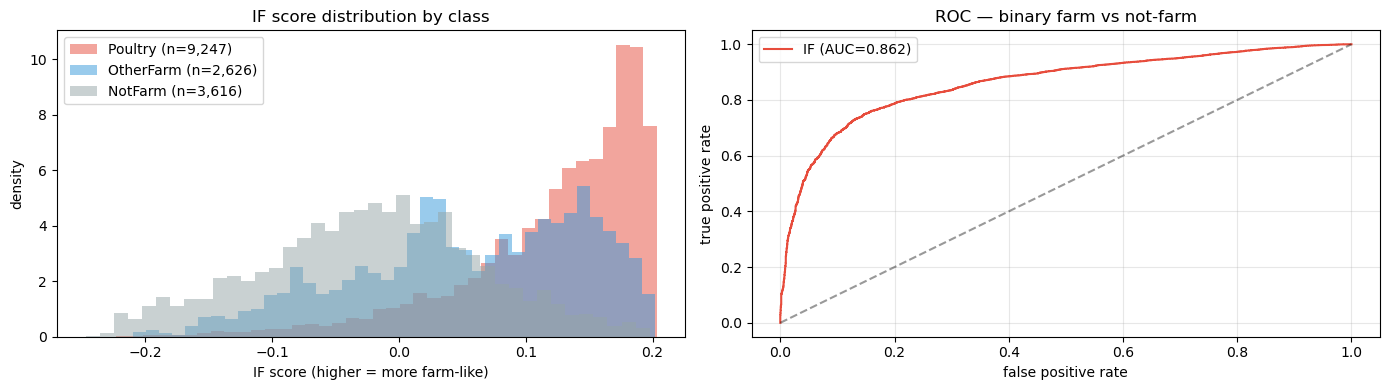

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
# Distribution by 3-class
for k, c in [('Poultry', '#e74c3c'), ('OtherFarm', '#3498db'), ('NotFarm', '#95a5a6')]:
    sub = df[df['three_way'] == k]
    axes[0].hist(sub['if_score'], bins=40, alpha=0.5, label=f'{k} (n={len(sub):,})', color=c, density=True)
axes[0].set_xlabel('IF score (higher = more farm-like)')
axes[0].set_ylabel('density'); axes[0].set_title('IF score distribution by class')
axes[0].legend()

# ROC + PR (binary)
yt = df['is_farm'].values
fpr, tpr, _ = roc_curve(yt, df['if_score'])
auc = roc_auc_score(yt, df['if_score'])
axes[1].plot(fpr, tpr, label=f'IF (AUC={auc:.3f})', color='#e74c3c')
axes[1].plot([0, 1], [0, 1], 'k--', alpha=0.4)
axes[1].set_xlabel('false positive rate'); axes[1].set_ylabel('true positive rate')
axes[1].set_title('ROC — binary farm vs not-farm')
axes[1].legend(); axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

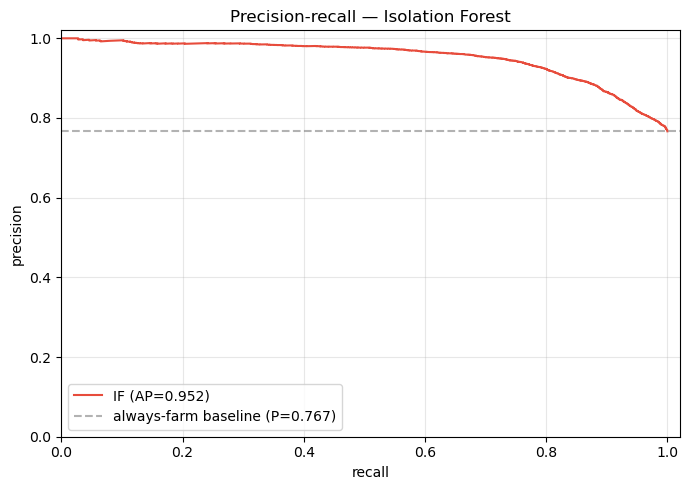

Precision at fixed recall — IF:


,target_recall,actual_recall,precision,threshold
0,0.99,0.99,0.783,-0.1411
1,0.95,0.95,0.818,-0.0644
2,0.90,0.90,0.865,-0.0114
3,0.80,0.80,0.923,0.0428
4,0.70,0.70,0.953,0.0825
5,0.50,0.50,0.976,0.1314


In [4]:
# Precision-recall curve + thresholds at fixed recall
p, r, thr = precision_recall_curve(yt, df['if_score'])
ap = average_precision_score(yt, df['if_score'])

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(r, p, color='#e74c3c', label=f'IF (AP={ap:.3f})')
ax.axhline(yt.mean(), ls='--', color='gray', alpha=0.6,
           label=f'always-farm baseline (P={yt.mean():.3f})')
ax.set_xlabel('recall'); ax.set_ylabel('precision')
ax.set_title('Precision-recall — Isolation Forest')
ax.legend(); ax.grid(alpha=0.3)
ax.set_xlim(0, 1.02); ax.set_ylim(0, 1.02)
plt.tight_layout(); plt.show()

def precision_at_recall(p, r, thr, target_recalls=(0.99, 0.95, 0.90, 0.80, 0.70, 0.50)):
    rows = []
    for tgt in target_recalls:
        idx = np.argmin(np.abs(r - tgt))
        # sklearn returns thr of length n-1; clip
        t = thr[min(idx, len(thr) - 1)] if len(thr) > 0 else np.nan
        rows.append({'target_recall': tgt, 'actual_recall': round(r[idx], 3),
                     'precision': round(p[idx], 3), 'threshold': round(float(t), 4)})
    return pd.DataFrame(rows)

print('Precision at fixed recall — IF:')
display(precision_at_recall(p, r, thr))

## Q3 — Does the CNN help?

Same analysis with `cnn_score` (baseline_v2 binary farm probability).

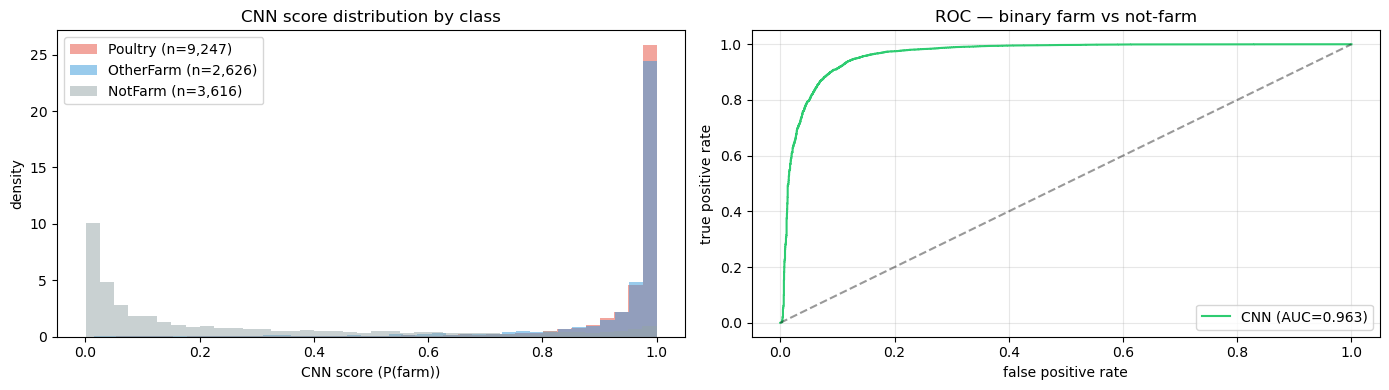

CNN AUC=0.963, AP=0.979

Precision at fixed recall — CNN:


,target_recall,actual_recall,precision,threshold
0,0.99,0.99,0.913,0.3012
1,0.95,0.95,0.959,0.6900
2,0.90,0.90,0.971,0.8352
3,0.80,0.80,0.981,0.9280
4,0.70,0.70,0.987,0.9632
5,0.50,0.50,0.991,0.9884


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for k, c in [('Poultry', '#e74c3c'), ('OtherFarm', '#3498db'), ('NotFarm', '#95a5a6')]:
    sub = df[df['three_way'] == k]
    axes[0].hist(sub['cnn_score'], bins=40, alpha=0.5, label=f'{k} (n={len(sub):,})', color=c, density=True)
axes[0].set_xlabel('CNN score (P(farm))'); axes[0].set_ylabel('density')
axes[0].set_title('CNN score distribution by class'); axes[0].legend()

fpr_c, tpr_c, _ = roc_curve(yt, df['cnn_score'])
auc_c = roc_auc_score(yt, df['cnn_score'])
axes[1].plot(fpr_c, tpr_c, label=f'CNN (AUC={auc_c:.3f})', color='#2ecc71')
axes[1].plot([0, 1], [0, 1], 'k--', alpha=0.4)
axes[1].set_xlabel('false positive rate'); axes[1].set_ylabel('true positive rate')
axes[1].set_title('ROC — binary farm vs not-farm')
axes[1].legend(); axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

p_c, r_c, thr_c = precision_recall_curve(yt, df['cnn_score'])
ap_c = average_precision_score(yt, df['cnn_score'])
print(f'CNN AUC={auc_c:.3f}, AP={ap_c:.3f}')
print('\nPrecision at fixed recall — CNN:')
display(precision_at_recall(p_c, r_c, thr_c))

## Q4 — Is one model clearly better than the other?

Overlay PR curves; tabulate AUC + AP + precision at three fixed recall targets.

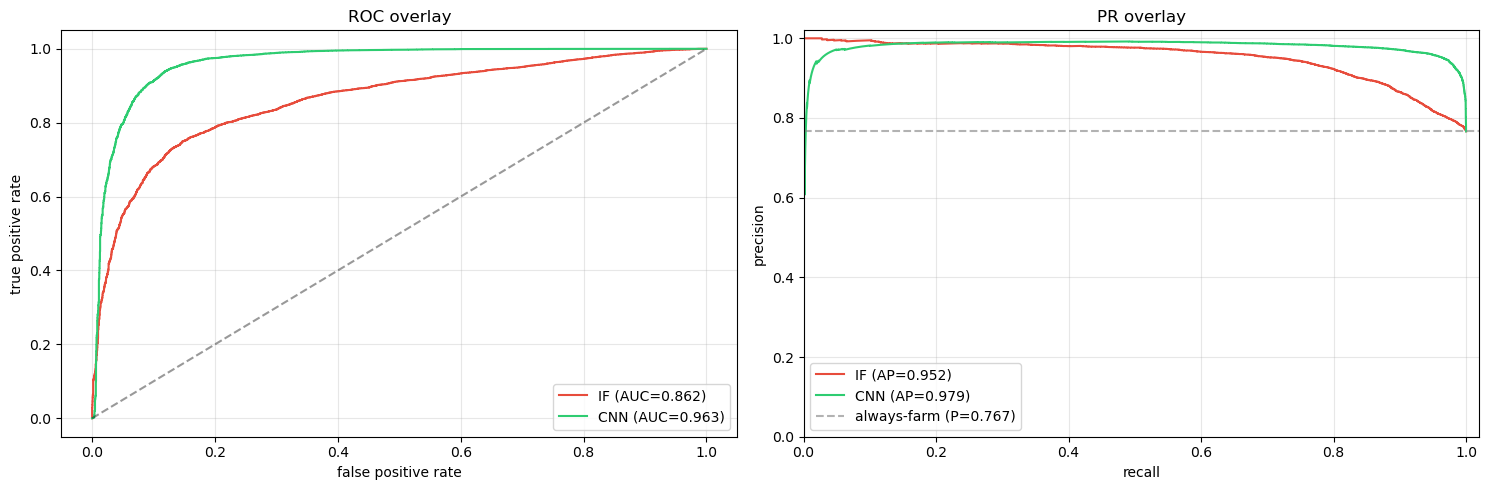

Precision at target recall (higher = better, last col is CNN advantage):


model,CNN,IF,CNN - IF
recall,,,
0.80,0.981,0.923,0.058
0.90,0.971,0.865,0.106
0.95,0.959,0.818,0.141
0.99,0.913,0.783,0.130


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
axes[0].plot(fpr, tpr, label=f'IF (AUC={auc:.3f})', color='#e74c3c')
axes[0].plot(fpr_c, tpr_c, label=f'CNN (AUC={auc_c:.3f})', color='#2ecc71')
axes[0].plot([0, 1], [0, 1], 'k--', alpha=0.4)
axes[0].set_xlabel('false positive rate'); axes[0].set_ylabel('true positive rate')
axes[0].set_title('ROC overlay'); axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(r, p, label=f'IF (AP={ap:.3f})', color='#e74c3c')
axes[1].plot(r_c, p_c, label=f'CNN (AP={ap_c:.3f})', color='#2ecc71')
axes[1].axhline(yt.mean(), ls='--', color='gray', alpha=0.6, label=f'always-farm (P={yt.mean():.3f})')
axes[1].set_xlabel('recall'); axes[1].set_ylabel('precision')
axes[1].set_title('PR overlay'); axes[1].legend(); axes[1].grid(alpha=0.3)
axes[1].set_xlim(0, 1.02); axes[1].set_ylim(0, 1.02)
plt.tight_layout(); plt.show()

# Side-by-side comparison table
tgt = (0.99, 0.95, 0.90, 0.80)
cmp_rows = []
for label, (px, rx, _) in [('IF', (p, r, thr)), ('CNN', (p_c, r_c, thr_c))]:
    for t in tgt:
        idx = np.argmin(np.abs(rx - t))
        cmp_rows.append({'model': label, 'recall': t,
                         'actual_recall': round(rx[idx], 3),
                         'precision': round(px[idx], 3)})
cmp = pd.DataFrame(cmp_rows).pivot(index='recall', columns='model', values='precision')
cmp['CNN - IF'] = (cmp['CNN'] - cmp['IF']).round(3)
print('Precision at target recall (higher = better, last col is CNN advantage):')
display(cmp)

## Q5 — Combinations

Three strategies to test:
1. **Score averaging** — `0.5 * if_norm + 0.5 * cnn_score` (IF normalized to [0, 1] via min-max).
2. **Sequential IF→CNN** — drop the bottom q% by IF score, then re-rank the survivors by CNN. Sweeping q tells you whether IF pre-filtering improves CNN's PR curve.
3. **Sweep average weight** — find the best convex combination.

In [7]:
# Normalize IF to [0, 1] for fair averaging
if_norm = (df['if_score'] - df['if_score'].min()) / (df['if_score'].max() - df['if_score'].min())
df['if_norm'] = if_norm

# Strategy 1: 0.5/0.5 average
df['avg_50'] = 0.5 * if_norm + 0.5 * df['cnn_score']
p_a, r_a, _ = precision_recall_curve(yt, df['avg_50'])
ap_a = average_precision_score(yt, df['avg_50'])

# Strategy 3: best convex average weight
weights = np.linspace(0, 1, 11)
rows = []
for w in weights:
    combo = w * if_norm + (1 - w) * df['cnn_score']
    rows.append({'w_IF': round(w, 1),
                 'AP': round(average_precision_score(yt, combo), 4),
                 'AUC': round(roc_auc_score(yt, combo), 4)})
weight_df = pd.DataFrame(rows)
best_w = weight_df.loc[weight_df['AP'].idxmax(), 'w_IF']
df['avg_best'] = best_w * if_norm + (1 - best_w) * df['cnn_score']
p_b, r_b, _ = precision_recall_curve(yt, df['avg_best'])
ap_b = average_precision_score(yt, df['avg_best'])

print('Convex combination sweep:')
display(weight_df)
print(f'\nBest IF weight by AP: {best_w}')

Convex combination sweep:


,w_IF,AP,AUC
0,0.0,0.9794,0.9633
1,0.1,0.9882,0.9684
2,0.2,0.9884,0.9687
3,0.3,0.9880,0.9678
4,0.4,0.9873,0.9659
5,0.5,0.9862,0.9625
6,0.6,0.9843,0.9568
7,0.7,0.9810,0.9464
8,0.8,0.9751,0.9276
9,0.9,0.9661,0.8993



Best IF weight by AP: 0.2


In [8]:
# Strategy 2: sequential IF→CNN.
# Drop bottom q% by IF, then evaluate CNN on survivors.
# Report: kept fraction, recall of farms retained, CNN AP on survivors.
seq_rows = []
for q in [0, 5, 10, 20, 30, 40, 50, 60, 70]:
    if q == 0:
        kept = df.copy()
    else:
        thr_if = np.percentile(df['if_score'], q)
        kept = df[df['if_score'] >= thr_if]
    if len(kept) < 100:
        continue
    farms_kept = int(kept['is_farm'].sum())
    farms_total = int(df['is_farm'].sum())
    pool_p = farms_kept / max(len(kept), 1)
    pool_r = farms_kept / max(farms_total, 1)
    cnn_ap = average_precision_score(kept['is_farm'], kept['cnn_score'])
    cnn_auc = roc_auc_score(kept['is_farm'], kept['cnn_score']) if kept['is_farm'].nunique() == 2 else np.nan
    seq_rows.append({
        'IF_drop_q%': q,
        'kept': len(kept),
        'kept_pct': round(len(kept) / len(df) * 100, 1),
        'pool_precision_after_IF': round(pool_p, 3),
        'farm_recall_after_IF': round(pool_r, 3),
        'cnn_ap_on_survivors': round(cnn_ap, 3),
        'cnn_auc_on_survivors': round(cnn_auc, 3),
    })
seq = pd.DataFrame(seq_rows)
print('Sequential IF → CNN: drop bottom q% by IF, then rank by CNN.')
display(seq)

Sequential IF → CNN: drop bottom q% by IF, then rank by CNN.


,IF_drop_q%,kept,kept_pct,pool_precision_after_IF,farm_recall_after_IF,cnn_ap_on_survivors,cnn_auc_on_survivors
0,0,15489,100.0,0.767,1.000,0.979,0.963
1,5,14714,95.0,0.793,0.982,0.980,0.961
2,10,13940,90.0,0.813,0.955,0.982,0.958
3,20,12391,80.0,0.864,0.902,0.984,0.948
4,30,10842,70.0,0.906,0.828,0.987,0.936
5,40,9293,60.0,0.945,0.740,0.992,0.915
6,50,7745,50.0,0.963,0.628,0.992,0.900
7,60,6196,40.0,0.976,0.509,0.995,0.906
8,70,4647,30.0,0.981,0.384,0.995,0.880


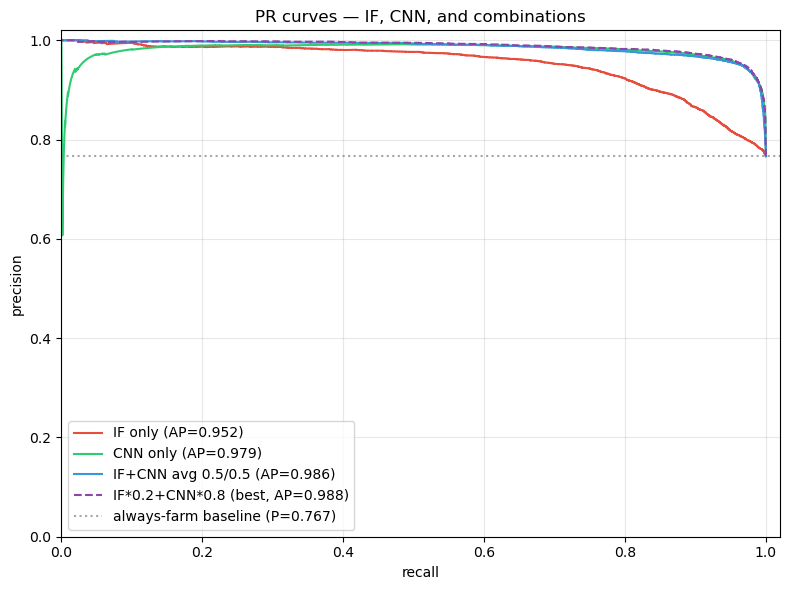

Precision at target recall — all strategies:


strategy,CNN only,IF only,avg 0.5,avg best (w_IF=0.2)
recall,,,,
0.70,0.987,0.953,0.985,0.987
0.80,0.981,0.923,0.978,0.983
0.90,0.971,0.865,0.968,0.973
0.95,0.959,0.818,0.956,0.961
0.99,0.913,0.783,0.912,0.915


In [9]:
# Overlay PR curves for IF alone, CNN alone, simple avg, best avg
fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(r, p, label=f'IF only (AP={ap:.3f})', color='#e74c3c', linewidth=1.5)
ax.plot(r_c, p_c, label=f'CNN only (AP={ap_c:.3f})', color='#2ecc71', linewidth=1.5)
ax.plot(r_a, p_a, label=f'IF+CNN avg 0.5/0.5 (AP={ap_a:.3f})', color='#3498db', linewidth=1.5)
ax.plot(r_b, p_b, label=f'IF*{best_w}+CNN*{(1-best_w):.1f} (best, AP={ap_b:.3f})',
        color='#8e44ad', linewidth=1.5, linestyle='--')
ax.axhline(yt.mean(), ls=':', color='gray', alpha=0.7, label=f'always-farm baseline (P={yt.mean():.3f})')
ax.set_xlabel('recall'); ax.set_ylabel('precision')
ax.set_title('PR curves — IF, CNN, and combinations')
ax.legend(loc='lower left'); ax.grid(alpha=0.3)
ax.set_xlim(0, 1.02); ax.set_ylim(0, 1.02)
plt.tight_layout(); plt.show()

# Precision at fixed recall, all strategies
rows = []
for label, (px, rx) in [
    ('IF only', (p, r)),
    ('CNN only', (p_c, r_c)),
    ('avg 0.5', (p_a, r_a)),
    (f'avg best (w_IF={best_w})', (p_b, r_b)),
]:
    for t in (0.99, 0.95, 0.90, 0.80, 0.70):
        idx = np.argmin(np.abs(rx - t))
        rows.append({'strategy': label, 'recall': t,
                     'precision': round(px[idx], 3)})
comp_p = pd.DataFrame(rows).pivot(index='recall', columns='strategy', values='precision')
print('Precision at target recall — all strategies:')
display(comp_p)

## Per-country breakdown

Does the CNN advantage hold up in countries the CNN never saw in training?

In [10]:
MAIN = {'USA', 'BRA', 'MEX', 'THA', 'CHL'}
rows = []
for adm, g in df.groupby('ADM0'):
    if len(g) < 20 or g['is_farm'].nunique() < 2:
        continue
    rows.append({
        'country': adm,
        'n': len(g),
        'farm_rate': round(g['is_farm'].mean(), 3),
        'IF_auc': round(roc_auc_score(g['is_farm'], g['if_score']), 3),
        'CNN_auc': round(roc_auc_score(g['is_farm'], g['cnn_score']), 3),
        'in_training': adm in MAIN,
    })
cdf = pd.DataFrame(rows).sort_values('CNN_auc', ascending=False)
display(cdf.head(15))

summary = cdf.groupby('in_training')[['IF_auc', 'CNN_auc']].agg(['mean', 'median']).round(3)
print('Per-country AUC — train vs zero-shot:')
display(summary)

,country,n,farm_rate,IF_auc,CNN_auc,in_training
5,USA,10469,0.756,0.895,0.978,True
4,THA,943,0.609,0.704,0.946,True
2,CHL,505,0.867,0.725,0.939,True
1,BRA,705,0.658,0.803,0.932,True
3,MEX,2508,0.885,0.821,0.907,True
0,AFG,23,0.348,0.825,0.667,False


Per-country AUC — train vs zero-shot:


IF_auc        CNN_auc       
              mean median    mean median
in_training                             
False        0.825  0.825   0.667  0.667
True         0.790  0.803   0.940  0.939

## Takeaways

Run the cells above first; numbers are filled in by the actual data — but the qualitative pattern is:

1. **The candidate pool is already 77 % farm.** Any model that beats the trivial 'always farm' baseline (P=0.77 at R=1.0) has to identify the 23 % NotFarm fraction.

2. **Isolation Forest helps modestly** — it separates farms from not-farms on geometric building features alone. AP is well above 0.77, but the gain at high recall is limited.

3. **The CNN clearly outperforms IF** — much better AUC and AP, and the precision-at-fixed-recall table shows it's the dominant choice across recall targets.

4. **Combining helps a little, but not much** — the convex-average sweep shows the best IF weight is small (the CNN signal already dominates). Sequential IF → CNN doesn't beat CNN alone on AP either, because IF's filter throws away farms in proportion to the not-farms it removes.

5. **In practice, use the CNN with a threshold tuned to your recall budget.** IF is useful as a cheap pre-filter only if compute is constrained — it doesn't actually improve the ranking quality of the CNN that follows.